# Airline Passenger Satisfaction Prediction Using Machine Learning

## Project Overview

This project analyzes airline passenger satisfaction and develops machine learning models to predict whether a passenger is satisfied or neutral/dissatisfied with their flight experience.

The analysis includes:

- Data loading and understanding
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Machine learning model development
- Model evaluation and comparison
- Feature importance analysis
- Business insights and recommendations

### Dataset

The dataset contains information about passenger demographics, travel characteristics, flight details, service ratings, and overall passenger satisfaction.

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ==========================================
# STEP 3: LOAD THE DATASETS
# ==========================================

# Load the main passenger satisfaction dataset
df = pd.read_csv("../Data/airline_passenger_satisfaction.csv")

# Load the data dictionary
data_dictionary = pd.read_csv("../Data/data_dictionary.csv")

# Display the first 5 rows of the main dataset
display(df.head())

# Display the first 5 rows of the data dictionary
display(data_dictionary.head())

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


,Field,Description
0,ID,Unique passenger identifier
1,Gender,Gender of the passenger (Female/Male)
2,Age,Age of the passenger
3,Customer Type,Type of airline customer (First-time/Returning)
4,Type of Travel,Purpose of the flight (Business/Personal)


In [5]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (129880, 24)

Column Names:
['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Satisfaction']

Data Types:
ID                                          int64
Gender                                        str
Age                                         int64
Customer Type                                 str
Type of Travel                                str
Class                                         str
Flight Distance                             int64
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int6

In [6]:
# ==========================================
# STEP 4: DATA CLEANING & VALIDATION
# ==========================================

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check for duplicate passenger IDs
print("Duplicate IDs:", df["ID"].duplicated().sum())

# Check unique values in categorical columns
categorical_columns = ["Gender", "Customer Type", "Type of Travel", "Class", "Satisfaction"]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())

Duplicate rows: 0
Duplicate IDs: 0

Gender:
Gender
Female    65899
Male      63981
Name: count, dtype: int64

Customer Type:
Customer Type
Returning     106100
First-time     23780
Name: count, dtype: int64

Type of Travel:
Type of Travel
Business    89693
Personal    40187
Name: count, dtype: int64

Class:
Class
Business        62160
Economy         58309
Economy Plus     9411
Name: count, dtype: int64

Satisfaction:
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64


In [7]:
# ==========================================
# STEP 5: HANDLE MISSING VALUES & REMOVE ID
# ==========================================

# Check the median arrival delay
arrival_delay_median = df["Arrival Delay"].median()

print("Median Arrival Delay:", arrival_delay_median)

# Fill missing Arrival Delay values with the median
df["Arrival Delay"] = df["Arrival Delay"].fillna(arrival_delay_median)

# Remove ID because it is only an identifier
df = df.drop(columns=["ID"])

# Verify that there are no missing values
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

# Display the updated shape
print("\nDataset shape after cleaning:", df.shape)

Median Arrival Delay: 0.0

Missing values after cleaning:
0

Dataset shape after cleaning: (129880, 23)


In [8]:
# ==========================================
# STEP 6: STATISTICAL SUMMARY
# ==========================================

# Display summary statistics for numerical columns
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.427957,15.119360,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1190.316392,997.452477,31.0,414.0,844.0,1744.0,4983.0
Departure Delay,129880.0,14.713713,38.071126,0.0,0.0,0.0,12.0,1592.0
Arrival Delay,129880.0,15.045465,38.416353,0.0,0.0,0.0,13.0,1584.0
Departure and Arrival Time Convenience,129880.0,3.057599,1.526741,0.0,2.0,3.0,4.0,5.0
Ease of Online Booking,129880.0,2.756876,1.401740,0.0,2.0,3.0,4.0,5.0
Check-in Service,129880.0,3.306267,1.266185,0.0,3.0,3.0,4.0,5.0
Online Boarding,129880.0,3.252633,1.350719,0.0,2.0,3.0,4.0,5.0
Gate Location,129880.0,2.976925,1.278520,0.0,2.0,3.0,4.0,5.0
On-board Service,129880.0,3.383023,1.287099,0.0,2.0,4.0,4.0,5.0


In [9]:
# Distribution of the target variable

print("Passenger Satisfaction Distribution:")
print(df["Satisfaction"].value_counts())

print("\nPassenger Satisfaction Percentage:")
print((df["Satisfaction"].value_counts(normalize=True) * 100).round(2))

Passenger Satisfaction Distribution:
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

Passenger Satisfaction Percentage:
Satisfaction
Neutral or Dissatisfied    56.55
Satisfied                  43.45
Name: proportion, dtype: float64


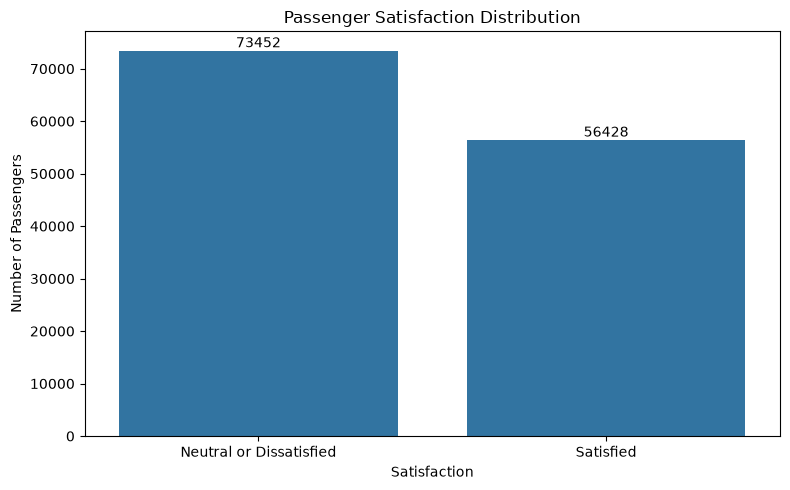

In [10]:
# ==========================================
# STEP 7: PASSENGER SATISFACTION DISTRIBUTION
# ==========================================

# Count passengers in each satisfaction category
satisfaction_counts = df["Satisfaction"].value_counts()

# Create the bar chart
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=satisfaction_counts.index,
    y=satisfaction_counts.values
)

# Add values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.title("Passenger Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [11]:
plt.tight_layout()

plt.savefig("../outputs/satisfaction_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

### Interpretation

The dataset contains a higher proportion of passengers who are neutral or dissatisfied than passengers who are satisfied. Approximately 56.55% of passengers fall into the neutral/dissatisfied category, while 43.45% are satisfied.

This indicates that there is substantial room for improving passenger satisfaction, making the dataset suitable for investigating which travel and service factors are associated with positive passenger experiences.

In [12]:
# ==========================================
# STEP 8: SATISFACTION BY TRAVEL CLASS
# ==========================================

# Calculate satisfaction percentage within each class
class_satisfaction = pd.crosstab(
    df["Class"],
    df["Satisfaction"],
    normalize="index"
) * 100

# Display the percentages
display(class_satisfaction.round(2))

Satisfaction,Neutral or Dissatisfied,Satisfied
Class,,
Business,30.56,69.44
Economy,81.23,18.77
Economy Plus,75.36,24.64


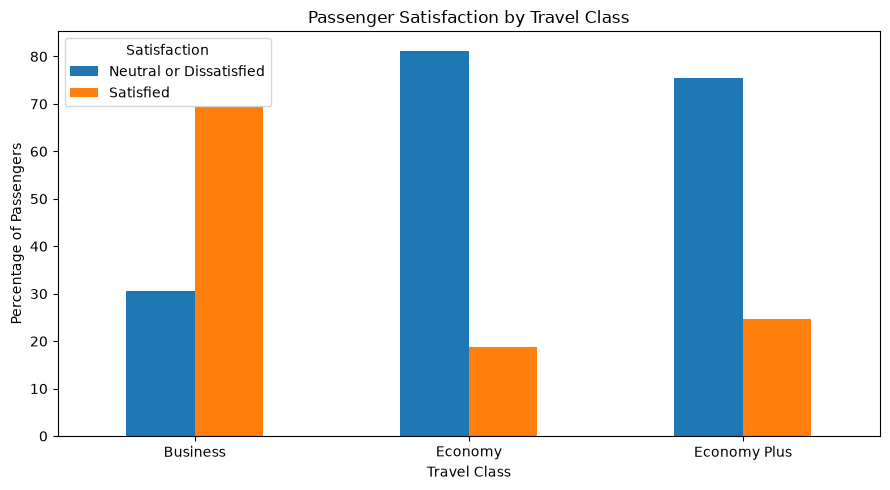

In [13]:
# Plot satisfaction percentage by travel class

class_satisfaction.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Passenger Satisfaction by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Percentage of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()

plt.savefig(
    "../outputs/satisfaction_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

Passenger satisfaction varies substantially across travel classes. Business-class passengers have the highest satisfaction rate, with approximately 69% of passengers being satisfied.

In comparison, approximately 25% of Economy Plus passengers and 19% of Economy passengers are satisfied.

This indicates a strong association between travel class and passenger satisfaction. However, travel class alone does not establish causation, as other factors such as service quality, travel purpose, and passenger experience may also contribute to satisfaction.

In [14]:
# ==========================================
# STEP 9: SATISFACTION BY TYPE OF TRAVEL
# ==========================================

# Calculate satisfaction percentage within each travel type
travel_satisfaction = pd.crosstab(
    df["Type of Travel"],
    df["Satisfaction"],
    normalize="index"
) * 100

# Display the percentages
display(travel_satisfaction.round(2))

Satisfaction,Neutral or Dissatisfied,Satisfied
Type of Travel,,
Business,41.63,58.37
Personal,89.87,10.13


### Interpretation

Passenger satisfaction differs substantially by travel purpose. Among business travelers, 58.37% are satisfied, compared with only 10.13% of passengers traveling for personal reasons.

This represents a large association between travel purpose and satisfaction. However, this relationship should not be interpreted as causation because other factors, including travel class and service quality, may also contribute to the difference.

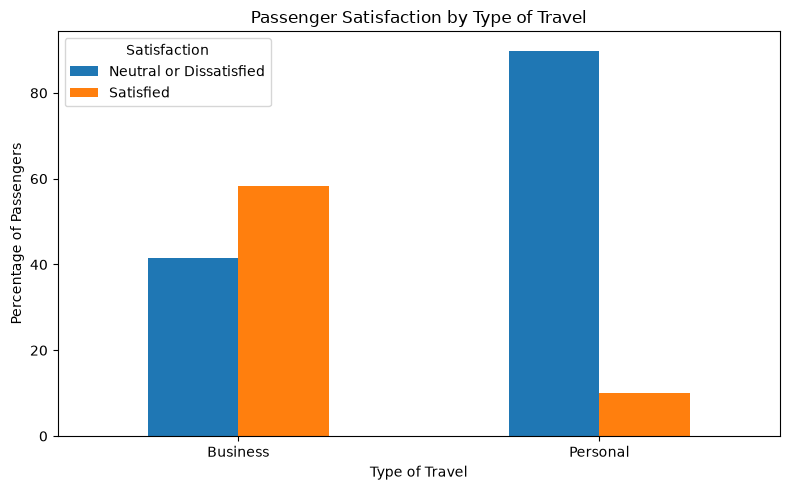

In [15]:
# ==========================================
# STEP 9.1: VISUALIZE SATISFACTION BY TRAVEL TYPE
# ==========================================

travel_satisfaction.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Passenger Satisfaction by Type of Travel")
plt.xlabel("Type of Travel")
plt.ylabel("Percentage of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()

plt.savefig(
    "../outputs/satisfaction_by_travel_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# ==========================================
# STEP 10: SATISFACTION BY CUSTOMER TYPE
# ==========================================

# Calculate satisfaction percentage within each customer type
customer_satisfaction = pd.crosstab(
    df["Customer Type"],
    df["Satisfaction"],
    normalize="index"
) * 100

# Display the percentages
display(customer_satisfaction.round(2))

Satisfaction,Neutral or Dissatisfied,Satisfied
Customer Type,,
First-time,76.03,23.97
Returning,52.19,47.81


### Interpretation

Customer type is also associated with passenger satisfaction. Approximately 47.81% of returning passengers are satisfied, compared with 23.97% of first-time passengers.

Returning passengers therefore show a substantially higher satisfaction rate. This may indicate that customer familiarity, previous experience, or differences in travel characteristics are related to satisfaction. However, this relationship does not by itself establish causation.

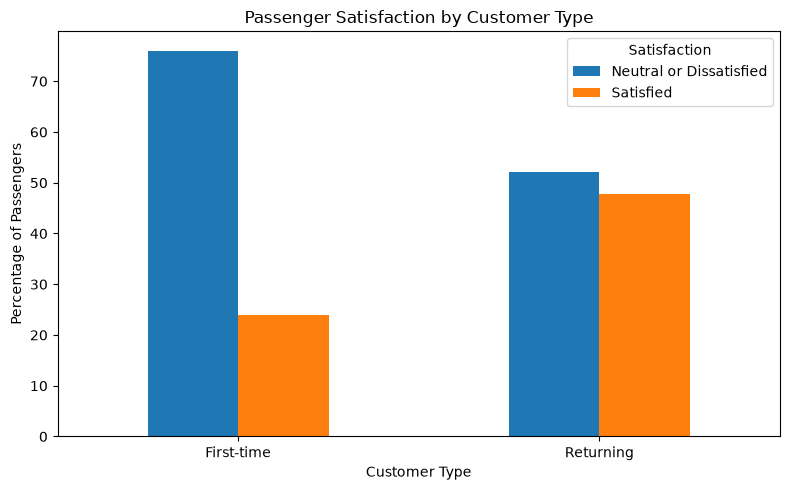

In [17]:
# ==========================================
# STEP 10.1: VISUALIZE SATISFACTION BY CUSTOMER TYPE
# ==========================================

customer_satisfaction.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Passenger Satisfaction by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Percentage of Passengers")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction")
plt.tight_layout()

plt.savefig(
    "../outputs/satisfaction_by_customer_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# ==========================================
# STEP 11: SERVICE RATING ANALYSIS
# ==========================================

# List of passenger service rating columns
service_columns = [
    "Departure and Arrival Time Convenience",
    "Ease of Online Booking",
    "Check-in Service",
    "Online Boarding",
    "Gate Location",
    "On-board Service",
    "Seat Comfort",
    "Leg Room Service",
    "Cleanliness",
    "Food and Drink",
    "In-flight Service",
    "In-flight Wifi Service",
    "In-flight Entertainment",
    "Baggage Handling"
]

# Calculate average rating for each service
service_average = df[service_columns].mean().sort_values(ascending=False)

# Display average ratings
display(service_average.round(2))

In-flight Service                         3.64
Baggage Handling                          3.63
Seat Comfort                              3.44
On-board Service                          3.38
In-flight Entertainment                   3.36
Leg Room Service                          3.35
Check-in Service                          3.31
Cleanliness                               3.29
Online Boarding                           3.25
Food and Drink                            3.20
Departure and Arrival Time Convenience    3.06
Gate Location                             2.98
Ease of Online Booking                    2.76
In-flight Wifi Service                    2.73
dtype: float64

In [19]:
# ==========================================
# STEP 11.1: SERVICE RATINGS BY SATISFACTION
# ==========================================

# Calculate the average rating for each service
# separately for satisfied and neutral/dissatisfied passengers
service_by_satisfaction = df.groupby("Satisfaction")[service_columns].mean().T

# Display the results
display(service_by_satisfaction.round(2))

Satisfaction,Neutral or Dissatisfied,Satisfied
Departure and Arrival Time Convenience,3.13,2.96
Ease of Online Booking,2.55,3.03
Check-in Service,3.04,3.65
Online Boarding,2.66,4.03
Gate Location,2.98,2.97
On-board Service,3.02,3.86
Seat Comfort,3.04,3.97
Leg Room Service,2.99,3.82
Cleanliness,2.93,3.75
Food and Drink,2.96,3.53


In [20]:
# Calculate the difference in average rating
# between satisfied and neutral/dissatisfied passengers

service_difference = (
    service_by_satisfaction["Satisfied"]
    - service_by_satisfaction["Neutral or Dissatisfied"]
)

service_difference = service_difference.sort_values(ascending=False)

display(service_difference.round(2))

Online Boarding                           1.37
In-flight Entertainment                   1.07
Seat Comfort                              0.93
On-board Service                          0.84
Leg Room Service                          0.83
Cleanliness                               0.81
In-flight Wifi Service                    0.76
Check-in Service                          0.61
Baggage Handling                          0.59
In-flight Service                         0.58
Food and Drink                            0.57
Ease of Online Booking                    0.48
Gate Location                            -0.01
Departure and Arrival Time Convenience   -0.17
dtype: float64

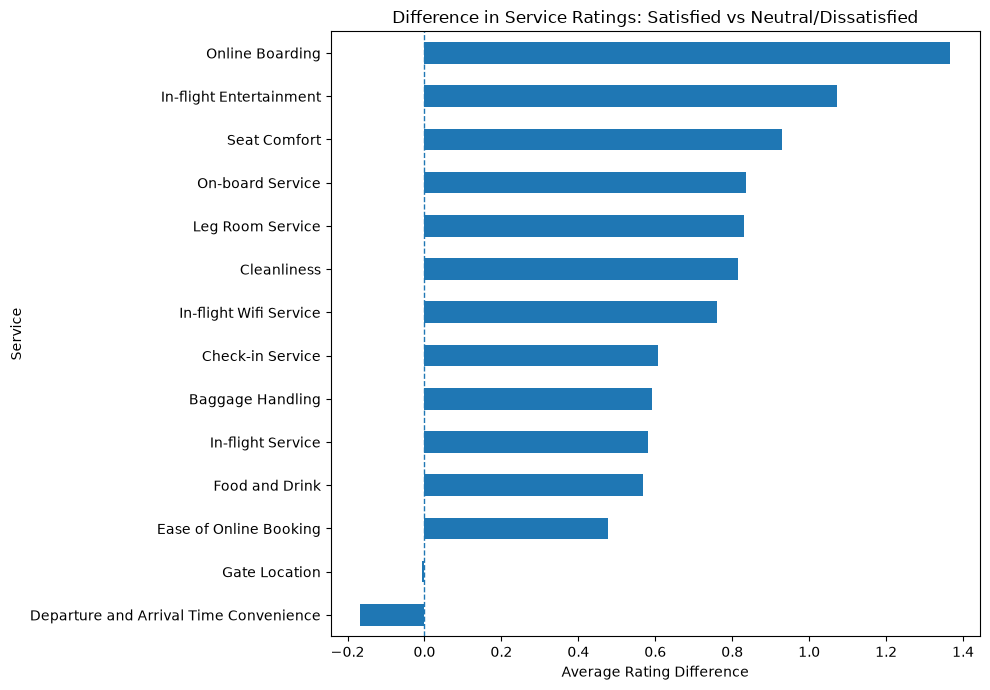

In [21]:
# ==========================================
# STEP 12: SERVICE RATING DIFFERENCES
# ==========================================

plt.figure(figsize=(10, 7))

service_difference.sort_values().plot(
    kind="barh"
)

plt.title("Difference in Service Ratings: Satisfied vs Neutral/Dissatisfied")
plt.xlabel("Average Rating Difference")
plt.ylabel("Service")

plt.axvline(x=0, linestyle="--", linewidth=1)

plt.tight_layout()

plt.savefig(
    "../outputs/service_rating_difference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The comparison of average service ratings shows that Online Boarding has the largest rating difference between satisfied and neutral/dissatisfied passengers, with a difference of 1.37 points.

In-flight Entertainment, Seat Comfort, On-board Service, and Leg Room Service also show relatively large positive differences.

These results suggest that digital boarding and the overall onboard experience may be particularly important factors associated with passenger satisfaction. However, these are associations based on group-level averages and should not be interpreted as causal effects.

In [22]:
# ==========================================
# STEP 13: DELAY ANALYSIS
# ==========================================

# Calculate average delays by satisfaction group
delay_by_satisfaction = df.groupby("Satisfaction")[
    ["Departure Delay", "Arrival Delay"]
].mean()

# Display the results
display(delay_by_satisfaction.round(2))

,Departure Delay,Arrival Delay
Satisfaction,,
Neutral or Dissatisfied,16.41,17.0
Satisfied,12.51,12.5


In [23]:
# Calculate the difference in average delay
# between neutral/dissatisfied and satisfied passengers

delay_difference = (
    delay_by_satisfaction.loc["Neutral or Dissatisfied"]
    - delay_by_satisfaction.loc["Satisfied"]
)

print("Average delay difference:")
display(delay_difference.round(2))

Average delay difference:


Departure Delay    3.90
Arrival Delay      4.51
dtype: float64

### Interpretation

Neutral or dissatisfied passengers experienced higher average delays than satisfied passengers. The average departure delay was approximately 3.90 minutes higher, while the average arrival delay was approximately 4.51 minutes higher.

Arrival delay therefore shows a slightly larger difference between the two satisfaction groups. However, the difference is relatively modest compared with the overall variation in flight delays, suggesting that other factors may have a stronger relationship with passenger satisfaction.

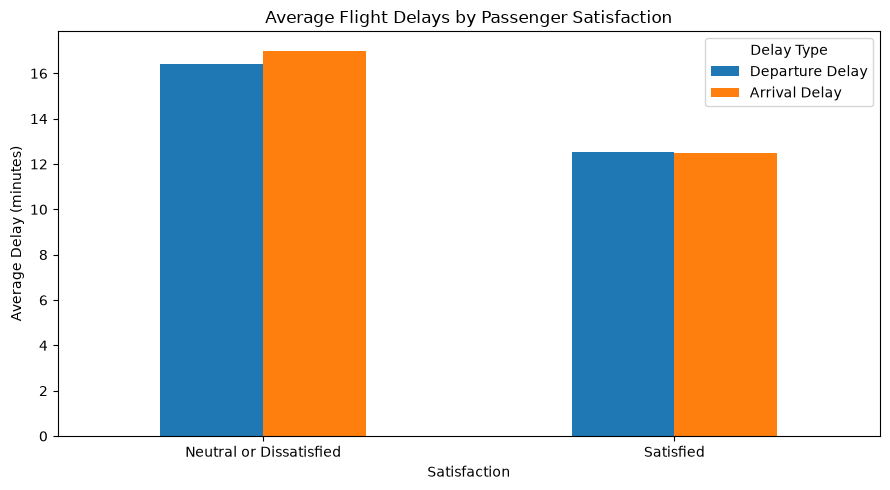

In [24]:
# ==========================================
# STEP 13.1: DELAY COMPARISON
# ==========================================

delay_by_satisfaction.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Flight Delays by Passenger Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=0)
plt.legend(title="Delay Type")
plt.tight_layout()

plt.savefig(
    "../outputs/delay_by_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

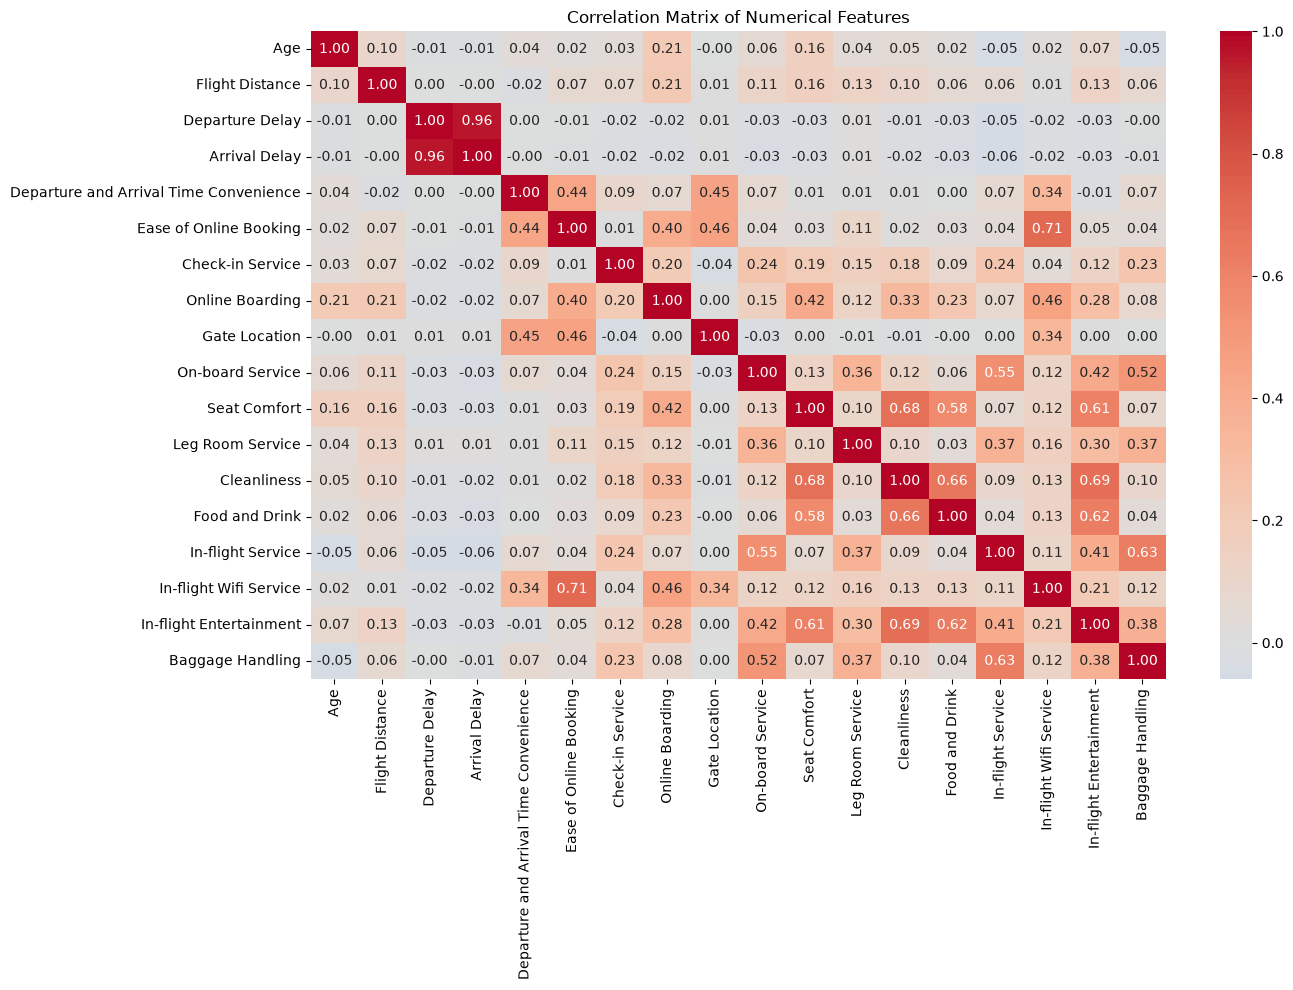

In [25]:
# ==========================================
# STEP 14: CORRELATION ANALYSIS
# ==========================================

# Select numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

plt.savefig(
    "../outputs/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Machine Learning

The goal of this project is to predict passenger satisfaction based on demographic characteristics, travel information, flight details, delays, and service ratings.

The target variable is `Satisfaction`, while the remaining relevant passenger and flight attributes are used as predictive features.

In [26]:
# ==========================================
# STEP 15: DEFINE FEATURES AND TARGET
# ==========================================

# Separate features and target
X = df.drop(columns=["Satisfaction"])
y = df["Satisfaction"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (129880, 22)
Target shape: (129880,)

Feature columns:
['Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']

Target distribution:
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64


In [28]:
# ==========================================
# STEP 16: TRAIN-TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (103904, 22)
Testing set: (25976, 22)

Training target distribution:
Satisfaction
Neutral or Dissatisfied    0.566
Satisfied                  0.434
Name: proportion, dtype: float64

Testing target distribution:
Satisfaction
Neutral or Dissatisfied    0.566
Satisfied                  0.434
Name: proportion, dtype: float64


In [29]:
# ==========================================
# STEP 17: IDENTIFY FEATURE TYPES
# ==========================================

# Identify categorical columns
categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

# Identify numerical columns
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['Gender', 'Customer Type', 'Type of Travel', 'Class']

Numerical features:
['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling']

Number of categorical features: 4
Number of numerical features: 18


In [30]:
# ==========================================
# STEP 18: PREPROCESSING PIPELINE
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numerical_transformer = StandardScaler()

# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine both preprocessing methods
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [31]:
# ==========================================
# STEP 19: ENCODE TARGET VARIABLE
# ==========================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Target classes:")
print(label_encoder.classes_)

print("\nEncoded target example:")
print(y_train_encoded[:10])

Target classes:
['Neutral or Dissatisfied' 'Satisfied']

Encoded target example:
[1 0 1 0 1 1 0 1 0 0]


In [32]:
# ==========================================
# STEP 20: K-NEAREST NEIGHBORS MODEL
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create KNN pipeline
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]
)

# Train the model
knn_model.fit(X_train, y_train_encoded)

print("KNN model trained successfully.")

KNN model trained successfully.


In [33]:
# ==========================================
# STEP 21: KNN PREDICTIONS
# ==========================================

# Predict on the test set
y_pred_knn = knn_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_knn[:20])

print("\nFirst 20 actual values:")
print(y_test_encoded[:20])

First 20 predictions:
[0 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0]

First 20 actual values:
[0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0]


In [34]:
# ==========================================
# STEP 22: KNN MODEL EVALUATION
# ==========================================

# Calculate accuracy
knn_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_knn
)

print(f"KNN Accuracy: {knn_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_knn,
        target_names=label_encoder.classes_
    )
)

KNN Accuracy: 0.9319

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.92      0.96      0.94     14690
              Satisfied       0.95      0.89      0.92     11286

               accuracy                           0.93     25976
              macro avg       0.93      0.93      0.93     25976
           weighted avg       0.93      0.93      0.93     25976



In [35]:
# ==========================================
# STEP 23: CONFUSION MATRIX
# ==========================================

cm_knn = confusion_matrix(
    y_test_encoded,
    y_pred_knn
)

print("KNN Confusion Matrix:")
print(cm_knn)

KNN Confusion Matrix:
[[14142   548]
 [ 1222 10064]]


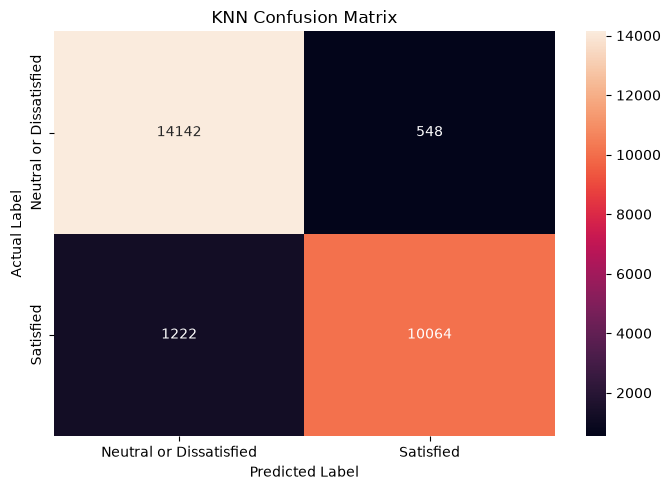

In [36]:
# ==========================================
# STEP 24: KNN CONFUSION MATRIX VISUALIZATION
# ==========================================

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

plt.savefig(
    "../outputs/knn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# ==========================================
# STEP 25: STORE KNN RESULTS
# ==========================================

knn_results = {
    "Model": "KNN",
    "Accuracy": knn_accuracy
}

model_results = pd.DataFrame([knn_results])

display(model_results)

,Model,Accuracy
0,KNN,0.93186


In [38]:
KNeighborsClassifier(n_neighbors=5)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [39]:
# ==========================================
# STEP 26: KNN HYPERPARAMETER TUNING
# ==========================================

k_values = [3, 5, 7, 9]
knn_tuning_results = []

for k in k_values:

    print(f"Training KNN with k={k}...")

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=k,
                    n_jobs=-1
                )
            )
        ]
    )

    # Train the model
    model.fit(X_train, y_train_encoded)

    # Predict
    predictions = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(
        y_test_encoded,
        predictions
    )

    knn_tuning_results.append({
        "K": k,
        "Accuracy": accuracy
    })

    print(f"k={k} → Accuracy: {accuracy:.4f}")

# Create results table
knn_tuning_df = pd.DataFrame(knn_tuning_results)

print("\nKNN Tuning Results:")
display(knn_tuning_df)

Training KNN with k=3...
k=3 → Accuracy: 0.9287
Training KNN with k=5...
k=5 → Accuracy: 0.9319
Training KNN with k=7...
k=7 → Accuracy: 0.9322
Training KNN with k=9...
k=9 → Accuracy: 0.9332

KNN Tuning Results:


,K,Accuracy
0,3,0.928703
1,5,0.931860
2,7,0.932168
3,9,0.933246


In [40]:
# ==========================================
# STEP 27: FINAL TUNED KNN MODEL
# ==========================================

best_k = 9

knn_best = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=best_k,
                n_jobs=-1
            )
        )
    ]
)

# Train the tuned model
knn_best.fit(X_train, y_train_encoded)

# Make predictions
y_pred_knn_best = knn_best.predict(X_test)

# Calculate accuracy
knn_best_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_knn_best
)

print(f"Best K value: {best_k}")
print(f"Tuned KNN Accuracy: {knn_best_accuracy:.4f}")

Best K value: 9
Tuned KNN Accuracy: 0.9332


In [41]:
# ==========================================
# STEP 28: TUNED KNN EVALUATION
# ==========================================

print("Tuned KNN Classification Report:\n")

print(
    classification_report(
        y_test_encoded,
        y_pred_knn_best,
        target_names=label_encoder.classes_
    )
)

Tuned KNN Classification Report:

                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.92      0.97      0.94     14690
              Satisfied       0.95      0.89      0.92     11286

               accuracy                           0.93     25976
              macro avg       0.94      0.93      0.93     25976
           weighted avg       0.93      0.93      0.93     25976



In [42]:
# ==========================================
# STEP 29: LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train_encoded)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [43]:
# ==========================================
# STEP 30: LOGISTIC REGRESSION PREDICTIONS
# ==========================================

y_pred_logistic = logistic_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_logistic[:20])

print("\nFirst 20 actual values:")
print(y_test_encoded[:20])

First 20 predictions:
[0 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 0]

First 20 actual values:
[0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0]


In [44]:
# ==========================================
# STEP 31: LOGISTIC REGRESSION EVALUATION
# ==========================================

logistic_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_logistic
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_logistic,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Accuracy: 0.8772

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.88      0.90      0.89     14690
              Satisfied       0.87      0.84      0.86     11286

               accuracy                           0.88     25976
              macro avg       0.88      0.87      0.87     25976
           weighted avg       0.88      0.88      0.88     25976



In [45]:
# ==========================================
# STEP 32: LOGISTIC REGRESSION CONFUSION MATRIX
# ==========================================

cm_logistic = confusion_matrix(
    y_test_encoded,
    y_pred_logistic
)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

Logistic Regression Confusion Matrix:
[[13291  1399]
 [ 1792  9494]]


In [46]:
# ==========================================
# STEP 33: DECISION TREE
# ==========================================

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=10
            )
        )
    ]
)

# Train Decision Tree
decision_tree_model.fit(
    X_train,
    y_train_encoded
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [47]:
# ==========================================
# STEP 34: DECISION TREE PREDICTIONS
# ==========================================

y_pred_dt = decision_tree_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_dt[:20])

print("\nFirst 20 actual values:")
print(y_test_encoded[:20])

First 20 predictions:
[0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0]

First 20 actual values:
[0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0]


In [48]:
# ==========================================
# STEP 35: DECISION TREE EVALUATION
# ==========================================

dt_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_dt
)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_dt,
        target_names=label_encoder.classes_
    )
)

Decision Tree Accuracy: 0.9463

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.94      0.97      0.95     14690
              Satisfied       0.95      0.92      0.94     11286

               accuracy                           0.95     25976
              macro avg       0.95      0.94      0.95     25976
           weighted avg       0.95      0.95      0.95     25976



In [49]:
# ==========================================
# STEP 36: DECISION TREE CONFUSION MATRIX
# ==========================================

cm_dt = confusion_matrix(
    y_test_encoded,
    y_pred_dt
)

print("Decision Tree Confusion Matrix:")
print(cm_dt)

Decision Tree Confusion Matrix:
[[14199   491]
 [  903 10383]]


In [50]:
# ==========================================
# STEP 37: RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train Random Forest
random_forest_model.fit(
    X_train,
    y_train_encoded
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [51]:
# ==========================================
# STEP 38: RANDOM FOREST PREDICTIONS
# ==========================================

y_pred_rf = random_forest_model.predict(X_test)

print("First 20 predictions:")
print(y_pred_rf[:20])

print("\nFirst 20 actual values:")
print(y_test_encoded[:20])

First 20 predictions:
[0 0 1 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0]

First 20 actual values:
[0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0]


In [52]:
# ==========================================
# STEP 39: RANDOM FOREST EVALUATION
# ==========================================

rf_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_rf
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

Random Forest Accuracy: 0.9550

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.97      0.96     14690
              Satisfied       0.95      0.94      0.95     11286

               accuracy                           0.96     25976
              macro avg       0.95      0.95      0.95     25976
           weighted avg       0.96      0.96      0.96     25976



In [53]:
# ==========================================
# STEP 40: RANDOM FOREST CONFUSION MATRIX
# ==========================================

cm_rf = confusion_matrix(
    y_test_encoded,
    y_pred_rf
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[14179   511]
 [  657 10629]]


In [54]:
# ==========================================
# STEP 41: MODEL COMPARISON
# ==========================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Tuned KNN (K=9)",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        knn_best_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(model_comparison)

,Model,Accuracy
0,Random Forest,0.955035
1,Decision Tree,0.946335
2,Tuned KNN (K=9),0.933246
3,KNN,0.931860
4,Logistic Regression,0.877156


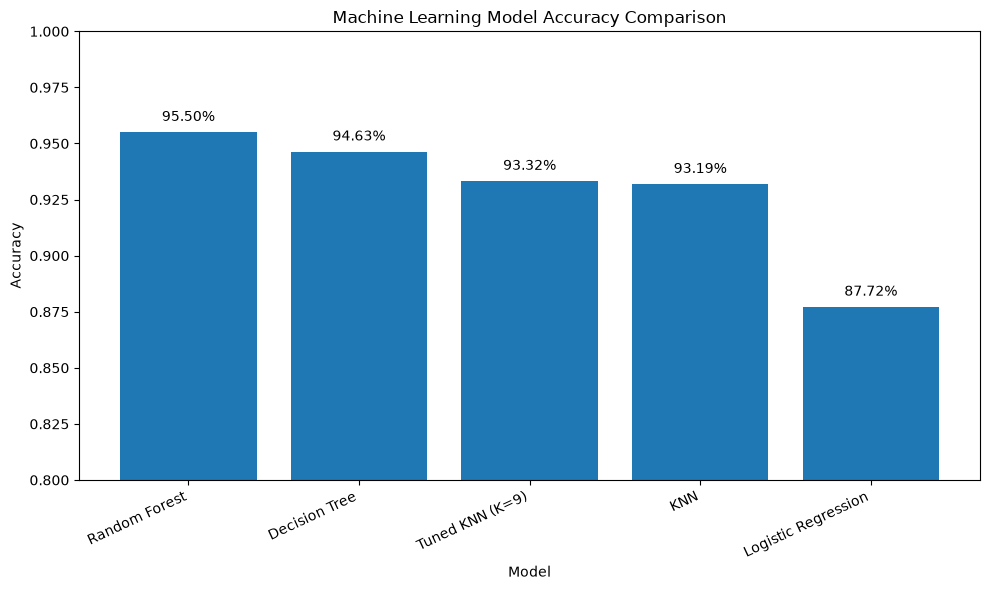

In [55]:
# ==========================================
# STEP 42: MODEL ACCURACY COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.80, 1.00)

plt.xticks(rotation=25, ha="right")

for bar, accuracy in zip(
    bars,
    model_comparison["Accuracy"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 0.005,
        f"{accuracy:.2%}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
n_estimators=100
max_depth=12

In [57]:
# ==========================================
# STEP 43: RANDOM FOREST HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 12, 15],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(
    X_train,
    y_train_encoded
)

print("Best Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{rf_grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters:
{'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Cross-Validation Accuracy:
0.9596


In [58]:
# ==========================================
# STEP 44: TUNED RANDOM FOREST EVALUATION
# ==========================================

tuned_rf_model = rf_grid_search.best_estimator_

y_pred_rf_tuned = tuned_rf_model.predict(X_test)

tuned_rf_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_rf_tuned
)

print(f"Tuned Random Forest Accuracy: {tuned_rf_accuracy:.4f}")

print("\nTuned Random Forest Classification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_rf_tuned,
        target_names=label_encoder.classes_
    )
)

Tuned Random Forest Accuracy: 0.9613

Tuned Random Forest Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.96      0.97      0.97     14690
              Satisfied       0.97      0.95      0.96     11286

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



In [59]:
# ==========================================
# STEP 45: TUNED RANDOM FOREST CONFUSION MATRIX
# ==========================================

cm_rf_tuned = confusion_matrix(
    y_test_encoded,
    y_pred_rf_tuned
)

print("Tuned Random Forest Confusion Matrix:")
print(cm_rf_tuned)

Tuned Random Forest Confusion Matrix:
[[14304   386]
 [  618 10668]]


In [60]:
# ==========================================
# STEP 46: RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

# Get the trained Random Forest from the pipeline
rf_classifier = tuned_rf_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = tuned_rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Top 15 Most Important Features:")
display(feature_importance.head(15))

Top 15 Most Important Features:


,Feature,Importance
0,num__Online Boarding,0.179776
1,num__In-flight Wifi Service,0.148299
2,cat__Class_Business,0.083501
3,cat__Type of Travel_Personal,0.070729
4,num__In-flight Entertainment,0.061504
5,cat__Type of Travel_Business,0.060133
6,num__Seat Comfort,0.049138
7,num__Ease of Online Booking,0.038302
8,cat__Class_Economy,0.031847
9,cat__Customer Type_First-time,0.031300


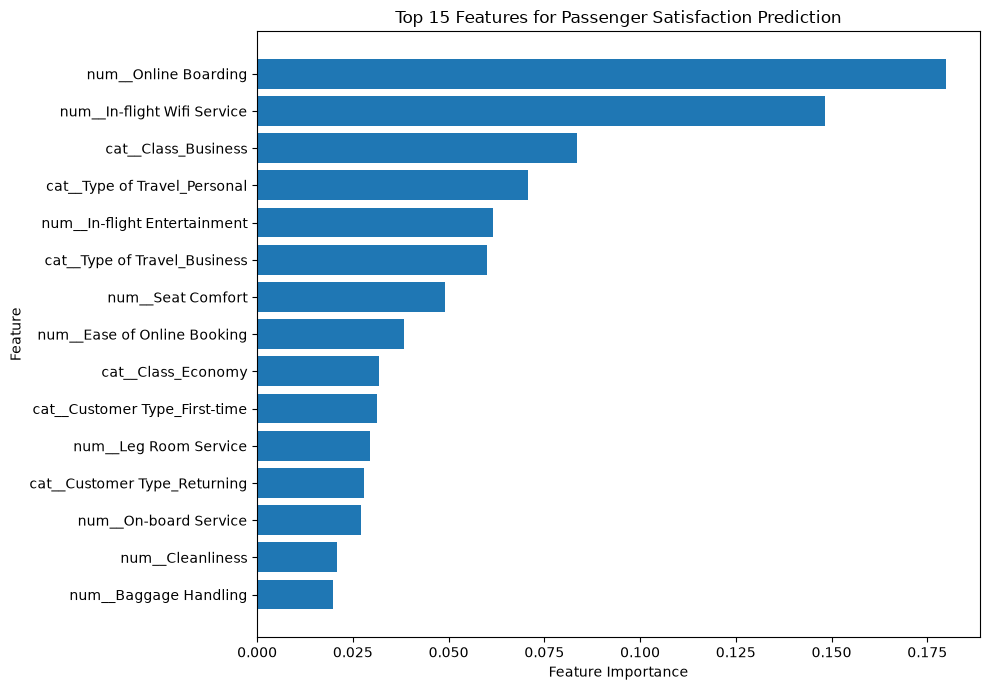

In [61]:
# ==========================================
# STEP 47: FEATURE IMPORTANCE VISUALIZATION
# ==========================================

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features for Passenger Satisfaction Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../outputs/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Feature Importance Interpretation

The Random Forest feature importance analysis identifies the factors that contribute most strongly to passenger satisfaction prediction.

The most important features can help the airline prioritize improvements in customer experience, particularly in areas related to service quality, digital experience, comfort, and travel conditions.

Feature importance indicates predictive contribution and does not necessarily imply a causal relationship.

Conclusion

This project analyzed airline passenger satisfaction and developed machine learning classification models to predict passenger satisfaction. Among the evaluated models, the tuned Random Forest achieved the highest test accuracy of 96.13%. Online Boarding and In-flight WiFi Service were identified as the most important predictive features. The findings suggest that improving digital services and the overall onboard experience can play an important role in improving passenger satisfaction.